# Лекция 2. Форматы представления действительных чисел (vol.2). Векторные и матричные нормы

## На прошлой лекции

- Введение
- Числа с фиксированной точкой
- Числа с плавающей точкой: одинарная, двойная и половинная точности
- Потеря точности при операциях с числами в формате плавающей точки

## План на сегодня

- Форматы чисел с плавающей точкой для обучения нейросетей
- Векторы
- Векторные нормы
- Матричные нормы

## Но сначала рассмотрим простой пример

- Как решить квадратное уравнение устойчиво ?
  $$ ax^2 + bx + c = 0 $$
- Наивная формула $$ x_{1,2} = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a} $$
  может давайть существенно неточный ответ.
- Давайте проверим!

In [1]:
import numpy as np

a = np.float32(1)
b = np.float32(100)
c = np.float32(1)

x1 = (-b + np.sqrt(b*b - 4*a*c, dtype=np.float32)) / (2 * a)
x2 = (-b - np.sqrt(b*b - 4*a*c, dtype=np.float32)) / (2 * a)
print(x1, x2)
print(a * x1 * x1 + b * x1 + c)
print(a * x2 * x2 + b * x2 + c)

-0.010002136 -99.99
-0.00011360645
0.0


## Почему случилась потеря точности?

- Вычитание больших чисел – потенциально неточная операция!
- Давайте вычислим корни без её использования
- Корень $x_2$ найден достаточно точно. Как по корню $x_2$ восстановить корень $x_1$?
- Теорема Виета нам поможет!

In [2]:
x1_precise = c / x2
print(a * x1 * x1 + b * x1 + c)
print(a * x1_precise * x1_precise + b * x1_precise + c)
x2_precise = -b - x1_precise
print(a * x2_precise * x2_precise + b * x2_precise + c)

-0.00011360645
0.0
0.0


## Выводы по операциям с числами с плавающей точкой

- Существуют различные форматы и подходы к хранению чисел в памяти
- Операции с числами с плавающей точкой могут приводить к неточным ответам из-за ошибок округления - требуется осторожность!
- Для многих стандартных алгоритмов вопросы устойчивости хорошо изучены и проблемы, связанные с этим, легко обнаруживаются.

## Обсудим как форматы чисел влияют на обучение нейросетей

### Кратко про нейросети
- Элементарные функции могут быть параметризованы, например $f(x) = Wx + b$ – линейная функция с параметрами $W$ и $b$
- Нейросеть – это суперпозиция параметрических функций
- Параметры элементарных функций, из которых состоит нейросеть, задаются с помощью чисел с плавающей точкой
- Формат хранения параметров напрямую влияет на то, насколько точно и устойчиво будет вычисляться итоговый результат
- Сравнение теоретических результатов о нейросетях и их практической реализации для чисел в формате плавающей точки проанализировано в [этой работе](https://link.springer.com/article/10.1007/s10444-024-10106-x)

### Форматы представления чисел и нейронные сети

- Для быстрой и энергоэффективной работы с нейросетями разработаны специальные форматы хранения чисел (подробности далее)
- Они помогают ускорить получение обученных моделей с некоторой потерей точности промежуточных вычислений

## Влияние формата представления чисел на обучение нейросетей

- Веса в слоях (полносвязном, свёрточном, действие функций активации) могут храниться с различной точностью
- Это важно для повышении энергоэффективности устройств, на которых запускается обученная нейросеть
- Проект [DeepFloat](https://github.com/facebookresearch/deepfloat) от Facebook показывает, как переизобрести операции с плавающей точкой, чтобы они были эффективны для обучения нейросетей, подробности см. в [статье](https://arxiv.org/pdf/1811.01721.pdf)
- Влияние формата представления чисел на значения градиентов активаций

<img width=500, src="./grad_norm_fp16.png">

- И на кривые обучения

<img width=500, src="./train_val_curves.png">

Графики взяты из [этой статьи](https://arxiv.org/pdf/1710.03740.pdf%EF%BC%89%E3%80%82)

- Проект [bitsandbytes](https://github.com/TimDettmers/bitsandbytes) предлагает ядра для CUDA, где реализованы базовые операции с малобитным представлением чисел

## bfloat16 (Brain Floating Point)

- Этот формат требует 16 битов
    - 1 бит для знака
    - 8 битов для экспоненты
    - 7 bits для мантиссы
    <img src="./bfloat16.png">
- Усечённая одинарная точность из стандарта IEEE
- Какая разница между float32 и float16?
- Этот формат используется в Intel FPGA, Google TPU, Xeon CPUs и других платформах

## Tensor Float от Nvidia ([блог об этом формате](https://blogs.nvidia.com/blog/2020/05/14/tensorfloat-32-precision-format/))

- Сравнение с другими форматами

<img src="./tensor_float_cf.png">

- Результаты

<img src="./TF32-BERT.png">

- PyTorch и Tensorflow, поддерживающие этот формат, доступны в [Nvidia NGC](https://ngc.nvidia.com/catalog/all)

## Смешанная точность ([документация от Nvidia](https://docs.nvidia.com/deeplearning/performance/mixed-precision-training/index.html))

- Основная идея:
    - Поддерживать копии весов в одинарной точности
    - Тогда на каждой итерации
        - Сделать копию весов в половинной точности
        - Сделать проход вперёд с весами в половинной точности
        - Умножить значение функции ошибки на множитель $S$
        - Вычислить градиент в половинной точности
        - Умножить градиенты весов на $1/S$
        - Обновить веса 
    - Множитель $S$ это гиперпараметр
    - Постоянный: такое значение, что его произведение на максимальное абсолютное значение градиента меньше чем 65504 (максимальное число, представимое в половинной точности).
    - Динамическое обновление, основанное на статистиках текущих градиентов
- Сравнение производительности
<img src="./mixed_precision_res.png" width=500>

- Существуют расширения для автоматического включения этой опции, больше подробностей [тут](https://developer.nvidia.com/automatic-mixed-precision)

## Резюме

- Числа с плавающей точкой – основа для проведения вычислений
- Использование нейросетей поставило новые вопросы и предъявило новые требования к числам и операциям с ними на уровне железа
- Помимо использования фиксированнго формата применяют смешанную точность

## Векторы

- В рамках курса, мы будем работать не с числами, а с векторами
- Вектор в фиксированном базисе размера $n$ может быть представлен как одномерный массив из $n$ чисел.
- Обычно вектор рассматривается, как матрица $n \times 1$, то есть вектор-столбец

**Примеры:** 
- Многочлены степени $\leq n$ образуют линейное пространство.
- Многочлен $ x^3 - 2x^2 + 1$ может быть представлен в виду вектора $\begin{bmatrix}1 \\ -2 \\ 0 \\ 1\end{bmatrix}$ в базисе $\{x^3, x^2, x, 1\}$

## Векторные нормы

- Векторы обычно содержат приближённое описание физических или каких-нибудь других объектов

- Один из главных вопросов – это насколько приближение точное (1%, 10%)

- Что является достаточно точным представлением объектов, конечно, зависит от конкретного приложения. Например:
    - При решении уравнений в частных производных чаще всего встречается точность порядка $10^{-5} - 10^{-10}$
    - Текущие приложения нейросетей к решению уравнений в частных производных часто дают точность $10^{-3} - 10^{-4}$. Графики ниже из [этой](https://arxiv.org/pdf/2006.11894.pdf) работы
    <img src="./pinns_loss.png">
    - В приложениях, связанных с обработкой данных, иногда точность порядка $80\%$ приемлема при серьёзном зашумлении исходных данных.

## Расстояния и нормы

- Норма – это количественная мера малости вектора, обычно обознается как $\Vert x \Vert$.

Норма должна удовлетворять следующим свойствам:

- $\Vert \alpha x \Vert = |\alpha| \Vert x \Vert$
- $\Vert x + y \Vert \leq \Vert x \Vert + \Vert y \Vert$ (неравенство треугольника)
- Если $\Vert x \Vert = 0$, то $x = 0$

Расстояние между двумя векторами можно определить как норму разности между ними

$$
   d(x, y) = \Vert x - y \Vert.
$$

## Стандартные нормы

Наиболее известная и чаще всего используемая норма – это **евклидова норма**:

$$\Vert x \Vert_2 = \sqrt{\sum_{i=1}^n |x_i|^2},$$

расстояние, по которой соответствует расстоянию в реальном мире. Если векторы состоят из комплексных чисел, используются их модули.

- $j^2 = -1$
-  $x_i = a + jb$
- $\bar{x}_i = a - jb$
- $|x_i|^2 = \bar{x}_i x_i = a^2 + b^2$

## $p$-норма

Евклидова норма или $2$-норма – это частный случай важного класса $p$-норм:

$$
 \Vert x \Vert_p = \Big(\sum_{i=1}^n |x_i|^p\Big)^{1/p}.
$$

Также важны следующие два частных случая :
- Бесконечная норма или Чебышёвская норма определяется как максимальный модуль элемента вектора $x$: 

$$
\Vert x \Vert_{\infty} = \max_i | x_i|
$$

<img src="./chebyshev.jpeg" style="height">

- $L_1$ норма определяется как сумма модулей элементов вектора $x$: 

$$
\Vert x \Vert_1 = \sum_i |x_i|
$$

Расстояние, определённое как $L_1$ норма разности между векторами, называется **Манхэттенским расстоянием**

<img src="./manhattan.jpeg" style="height">  


## Единичные диски в различных нормах

- Единичный диск – это множество точек такое что $\Vert x \Vert \leq 1$
- Для евклидовой нормы единичный диск сопадает с обычным диском
- Для других норм единичный диск сильно отличается от привычного нам диска

Text(0.5, 1.0, 'Unit disk in the p-th norm, $p=2$')

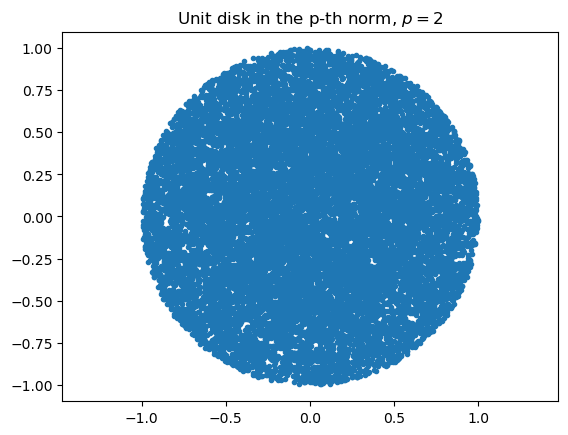

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
p = 2 # Which norm do we use
M = 40000 # Number of sampling points
a = np.random.randn(M, 2)
b = []
for i in range(M):
    if np.linalg.norm(a[i, :], p) <= 1:
        b.append(a[i, :])
b = np.array(b)
plt.plot(b[:, 0], b[:, 1], '.')
plt.axis('equal')
plt.title('Unit disk in the p-th norm, $p={0:}$'.format(p))

## Матрицы и матричные нормы

- Векторные нормы позволяли измерить размер вектора и расстояние между векторами

- Как обобщить эту концепцию на матрицы?

- Если считать матрицу вектором, элементы которого переставлены в другом порядке, то мы по аналогии с евклидовой нормой вектора получим фробениусову норму матрицы:

$$
  \Vert A \Vert_F \stackrel{\mathrm{def}}{=} \Big(\sum_{i=1}^n \sum_{j=1}^m |a_{ij}|^2\Big)^{1/2}
$$

## Матричные нормы

$\Vert \cdot \Vert$ называется матричной нормой, если это векторная норма на векторном пространстве матриц размера $n \times m$:
1. $\|A\| \geq 0$ и если $\|A\| = 0$ то $A = O$
3. $\|\alpha A\| = |\alpha| \|A\|$
4. $\|A+B\| \leq \|A\| + \|B\|$ (неравенство треугольника)

Дополнительно некоторые нормы обладают свойством субмультипликативности

* <font color='red'> $\Vert A B \Vert \leq \Vert A \Vert \Vert B \Vert$ </font>

Эти нормы также называются **субмультипликативными нормами**.

Это свойство необходимо во многих случаях, например для оценки ошибки решения линейной системы (позднее обсудим эту тему). 

Примером не субмультипликативной нормы является чебышёвская норма

$$
\|A\|_C = \displaystyle{\max_{i,j}}\, |a_{ij}|
$$

## Операторные нормы

Наиболее важным классом матричных норм являются **операторные нормы**, которые определяются следующим образом

$$
    \Vert A \Vert_{*,**} = \sup_{x \ne 0} \frac{\Vert A x \Vert_*}{\Vert x \Vert_{**}},
$$

где $\Vert \cdot \Vert_*$ и $\| \cdot \|_{**}$ **векторные нормы**.

Легко проверить, что операторные нормы являются субмультипликативными.

## Матричные $p$-нормы

Важный класс операторных норм – матричные $p$-нормы, которые определены для $\|\cdot\|_* = \|\cdot\|_{**} = \|\cdot\|_p$. <br>

Среди всех $p$-норм три нормы наиболее часто используются:  

- $p = 1, \quad \Vert A \Vert_{1} = \displaystyle{\max_j \sum_{i=1}^n} |a_{ij}|$.

- $p = 2, \quad$ спектральная норма, обозначается как $\Vert A \Vert_2$.

- $p = \infty, \quad \Vert A \Vert_{\infty} = \displaystyle{\max_i \sum_{j=1}^m} |a_{ij}|$.

## Выводы

- Нормы векторов обобщают понятие длины
- $p$-нормы – семейство стандартных векторных норм
- Матричные нормы
- Операторные нормы 